## Import modules and dependencies

In [622]:
import openseespywin as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [623]:
import sys
sys.path.append('Data')
import functions.RCs_section as RCS
import functions.analysis as anlyze
import functions.solver_function as esl
import functions.SmartAnalyze as smrt
import importlib
importlib.reload(RCS)
importlib.reload(anlyze)  
importlib.reload(esl)        
importlib.reload(smrt) 
from functions.RCs_section import *
from functions.analysis import *
from functions.solver_function import *
from functions.SmartAnalyze import *

In [624]:
convert_tcl = 'no'

In [625]:
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='ctcTest.tcl',
                output_file='ctcTest.py',
                prefix="ops")

## Basic Units

### Defaults  Units

In [626]:
# THESE ARE DEFAULT UNITS OF OPENSEES
mm = 1.0 # Meters
N = 1.0 # KiloNewtons
sec = 1.0 # Seconds

## Define Material Properties

### Concrete Material

### Steel Material

### Soil  Material

In [627]:
# Confinement Stress
pConf = -50.0

# Deviatoric strain
devDisp = -0.2

# Permeablity
perm = 1.0e-9

# Rayleigh damping parameters
# Set initial variables
damp = 0.1
omega1 = 0.0157
omega2 = 64.123

# Calculate a1 and a0
# In Python, multiplication is '*', division is '/', and parentheses '()' define order of operations.
a1 = 2.0 * damp / (omega1 + omega2)
a0 = a1 * omega1 * omega2

E = 90000.0
nu = 0.40

# Calculate G and B
G = E / (2.0 * (1.0 + nu))
B = E / (3.0 * (1.0 - 2.0 * nu))

## Framing and Fixities

### Initialize

In [628]:
AnalysisType = "transient" #transient Static Pushover Cyclic Pushover Gravity
AnalysisType_step2 = "no" # yes or no

In [629]:
ops.wipe()
#nodes_dict = dict()

### Framing

In [630]:
ops.model('basic', '-ndm', 3, '-ndf', 4)

ops.node(1, 1.0, 0.0, 0.0)
ops.node(2, 1.0, 1.0, 0.0)
ops.node(3, 0.0, 1.0, 0.0)
ops.node(4, 0.0, 0.0, 0.0)
ops.node(5, 1.0, 0.0, 1.0)
ops.node(6, 1.0, 1.0, 1.0)
ops.node(7, 0.0, 1.0, 1.0)
ops.node(8, 0.0, 0.0, 1.0)

### Fixities

In [631]:
ops.fix(1, 0, 1, 1, 1)
ops.fix(2, 0, 0, 1, 1)
ops.fix(3, 1, 0, 1, 1)
ops.fix(4, 1, 1, 1, 1)
ops.fix(5, 0, 1, 0, 1)
ops.fix(6, 0, 0, 0, 1)
ops.fix(7, 1, 0, 0, 1)
ops.fix(8, 1, 1, 0, 1)

### Equal DOFs

### Define Rigid Diaphragms

In [632]:
#opst.vis.plotly.plot_model()

## Define Tags

### Material Tags

In [633]:
mTag = 1
mDen = 1.8
fang = 31.4
ptang = 26.5
eNot = 0.7

### Section Tags

## Define the sections

### Section Tags

### Uniaxial Material

### nDmaterials

In [634]:
ops.nDMaterial('PressureDependMultiYield', mTag, 3, mDen, G, B,fang, 0.1, 80, 0.5, ptang, 0.17, 0.4, 10, 10, 0.015, 1.0)

### Fiber Section

### Elastic Section

### Soil Material

## Define Transformation

### Transformation Tags

### Section aggregation

### geometeric transformation

### Beam Integration

## Assemble the Model

In [635]:
fBulk = 2.2e6
fDen  = 1.0
alpha = 1.5e-5

ops.element('SSPbrickUP', 1, 1, 2, 3, 4, 5, 6, 7, 8, mTag, fBulk, fDen, perm, perm, perm, eNot, alpha)

In [636]:
#opst.vis.plotly.plot_model()

## Define Recorders

### Directory

In [637]:
dataDir = 'Data'
if not os.path.exists(dataDir):
    os.makedirs(dataDir)

# Define these variables before using them
OutputDirName = "Qcore_cTc"  # Change this as needed
AnalysisName = "examp"  # Change this as needed

# Construct the base directory and filename
baseDir = os.path.join('outputs', OutputDirName)
baseName = os.path.join(baseDir, AnalysisName)

# Ensure the base directory exists
if not os.path.exists(baseDir):
    os.makedirs(baseDir)

print(f"Recorder output path: {baseName}")  # Debugging output

Recorder output path: outputs\Qcore_cTc\examp


### Recorders

In [638]:
ops.recorder('Node', '-file', baseName + 'disp.out', '-time', '-nodeRange', 5, 8, '-dof', 3, 'disp')
ops.recorder('Node', '-file', baseName + 'press.out', '-time', '-nodeRange', 1, 8, '-dof', 4, 'vel')
# Record stress for elements with tags from 1 to 10
ops.recorder('Element', '-file', baseName + 'stress.out','-time',  '-ele', 1, 'stress')

# Record strain for elements with tags from 1 to 10
ops.recorder('Element', '-file', baseName + 'strain.out','-time',  '-ele', 1, 'strain')

63

## Loadings and Analysis

### time series and patterns tags

In [639]:
pNode = pConf / 4.0

tsTag = 1 # Using 1 as the tag for this time series
ops.timeSeries('Path', tsTag,
               '-values', 0, 1, 1, 
               '-time', 0.0, 10000.0, 1.0e10) # Global factor for the series

patternTag = 1 # Using 1 as the tag for this load pattern
ops.pattern('Plain', patternTag, tsTag, '-factor',1.0)

ops.load(1, pNode, 0.0, 0.0, 0.0) # Assuming loads for first 4 DOFs
ops.load(2, pNode, pNode, 0.0, 0.0)
ops.load(3, 0.0, pNode, 0.0, 0.0)
ops.load(5, pNode, 0.0, pNode, 0.0)
ops.load(6, pNode, pNode, pNode, 0.0)
ops.load(7, 0.0, pNode, pNode, 0.0)
ops.load(8, 0.0, 0.0, pNode, 0.0)

#### Pattern tags

### Define masses

### Analysis Parameters

### Gravity 

### Static Analysis

In [640]:
if(AnalysisType=="static"):
    
    ops.constraints('Plain',)
    ops.numberer('Plain',)
    ops.system('BandGeneral',)
    # ops.test('EnergyIncr', 1e-06, 200)
    # ops.algorithm('Newton',)
    # ops.integrator('DisplacementControl', 25, 1, 4)
    # ops.analysis('Static',)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, -8)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, 12)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, -16)
    # ops.analyze(50,)

    #protocol=[1,0,-10,-40,-80,-120,-400]
    protocol=[1,-1] #this value are the target displacement
    analysis = opst.anlys.SmartAnalyze(analysis_type="Static")
    segs = analysis.static_split(protocol, 0.1) #will the numner of steps 400/2.0 = 200 steps
    print(segs)
    for seg in segs:
        analysis.StaticAnalyze(node=4, dof=2, seg=seg)  # node tag 1, dof 2

In [641]:
if(AnalysisType_step2=="yes"):
    ops.loadConst('-time', 0.0)
    ops.timeSeries('Linear', 2)
    ops.pattern('Plain', 2, 2)
    ops.load(34, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(35, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(40, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(45, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(50, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(55, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(60, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(65, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(70, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(75, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(80, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(85, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(90, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(95, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(100, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(105, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(110, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(119, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(120, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(125, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(130, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(135, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(140, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(145, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    ops.load(150, 0.0, 0.0, -10000.0, 0.0, 0.0, 0.0)
    print('analysis')
    ops.constraints('Penalty', 1e+20, 1e+20)
    ops.numberer('RCM',)
    ops.system('UmfPack',)
    # ops.test('NormDispIncr', 0.0001, 1000, 2)
    # ops.algorithm('KrylovNewton',)
    # ops.integrator('DisplacementControl', 70, 3, -0.5)
    # ops.analysis('Static',)
    # ops.analyze(100,)
    protocol=[1.0, 0.5, 0,-1.0, -1.5, -50]
    analysis = opst.anlys.SmartAnalyze(analysis_type="Static")
    segs = analysis.static_split(protocol, 0.5)
    print(segs)
    for seg in segs:
        analysis.StaticAnalyze(node=70, dof=3, seg=seg)  # node tag 1, dof 2

### Pushover

In [642]:
if(AnalysisType=="Pushover"):
	
	print("<<<< Running Pushover Analysis >>>>")

	# create a plain load pattern for pushover analysis
	ops.pattern("Plain", 2, 1)
	
	ControlNode=53
	ControlDOF=1
	MaxDisp= 0.020
	DispIncr=0.00001
	NstepsPush=int(MaxDisp/DispIncr)
	
	ops.load(ControlNode, 1.00, 0.0, 0.0, 0.0, 0.0, 0.0)	# Apply a unit reference load in DOF=1
	
	ops.system("BandGeneral")
	ops.numberer("RCM")
	ops.constraints('Penalty',1e20,1e20)
	ops.integrator("DisplacementControl", ControlNode, ControlDOF, DispIncr)
	ops.algorithm('KrylovNewton')
	ops.test('NormDispIncr',1e-05, 1000, 2)
	ops.analysis("Static")
	
	# Create a folder to put the output
	PushDataDir = r'PushoverOut_shear'
	if not os.path.exists(PushDataDir):
		os.makedirs(PushDataDir)
	ops.recorder('Node', '-file', "PushoverOut/React.out", '-closeOnWrite', '-node', 1, 2, 3, 4, 5, '-dof',1, 'reaction')
	ops.recorder('Node', '-file', "PushoverOut/Disp.out", '-closeOnWrite', '-node', ControlNode, '-dof',1, 'disp')

	# Perform pushover analysis
	dataPush = np.zeros((NstepsPush+1,5))
	for j in range(NstepsPush):
		ops.analyze(1)
		dataPush[j+1,0] = ops.nodeDisp(ControlNode,1)*1000		# Convert to mm
		dataPush[j+1,1] = ops.getLoadFactor(2)*0.001			# Convert to kN
		
	# Read test output data to plot
	Test = np.loadtxt("Data/RCshearwall_TestOutput.txt", delimiter="\t", unpack="False")
	
	## Set parameters for the plot
	plt.rcParams.update({'font.size': 7})
	plt.figure(figsize=(4,3), dpi=100)
	plt.rc('font', family='serif')
	plt.plot(Test[0,:], Test[1,:], color="black", linewidth=0.8, linestyle="--", label='Test')
	plt.plot(dataPush[:,0], -dataPush[:,1], color="red", linewidth=1.2, linestyle="-", label='Pushover')
	plt.axhline(0, color='black', linewidth=0.4)
	plt.axvline(0, color='black', linewidth=0.4)
	plt.xlim(-25, 25)
	plt.xticks(np.linspace(-20,20,11,endpoint=True)) 
	plt.grid(linestyle='dotted') 
	plt.xlabel('Displacement (mm)')
	plt.ylabel('Base Shear (kN)')
	plt.legend()
	plt.savefig("PushoverOut_shear/RCshearwall_PushoverCurve.png",dpi=1200)
	plt.show()
	
	
	print("Pushover analysis complete")

### Cyclic

In [643]:
if(AnalysisType=="Cyclic"):
	
	# This is a load controlled analysis. The input load file "RCshearwall_Load_input.txt" should be in the 
	# .. same folder as the model file.
	
	print("<<<< Running Cyclic Analysis >>>>")
	
	ops.timeSeries('Path',2,'-dt',0.1,'-filePath','RCshearwall_Load_input.txt')
	ops.pattern('Plain',2,2)
	ops.sp(53,1,1)								# construct a single-point constraint object added to the LoadPattern.

	ops.constraints('Penalty',1e20,1e20)
	ops.numberer('RCM')
	ops.system('BandGeneral')
	ops.test('NormDispIncr',1e-05, 100, 1)
	ops.algorithm('KrylovNewton')
	ops.integrator('LoadControl',0.1)
	ops.analysis('Static')
	ops.analyze(700)

### Transient 

In [644]:
if(AnalysisType=="transient"):
    ops.constraints('Penalty', 1e+17, 1e+17)
    ops.test('NormDispIncr', 0.0001, 20, 1)
    ops.algorithm('Newton',)
    ops.numberer('RCM',)
    ops.system('BandGeneral',)
    ops.integrator('Newmark', 0.5, 0.25)
    ops.rayleigh(a0, 0.0, a1, 0.0)
    ops.analysis('Transient',)
    ops.analyze(100, 100)
    ops.analyze(10, 1000)
    #smrt.SmartAnalyzeTransient(dt, 1000)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84876e-06 (max: 0.0001, Norm R: 2.48253e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84924e-06 (max: 0.0001, Norm R: 3.34221e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84876e-06 (max: 0.0001, Norm R: 4.26389e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84924e-06 (max: 0.0001, Norm R: 2.6037e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84876e-06 (max: 0.0001, Norm R: 8.382e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84924e-06 (max: 0.0001, Norm R: 1.05325e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84876e-06 (max: 0.0001, Norm R: 1.45604e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84924e-06 (max: 0.0001, Norm R: 1.66163e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84876e-06 (max: 0.0001, Norm R: 7.69185e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 3.84924e-06 (max: 0.0

In [645]:
if(AnalysisType=="transient"):
    for x in range(1, 9):
    # Remove single point constraint (sp)
    # ops.remove('sp', nodeTag, dof)
    # Here, 'x' is the current node tag from the loop, and '4' is the DOF.
        ops.remove('sp', x, 4)
    
    ops.analyze(5, 0.1)
    ops.updateMaterialStage('-material', 1, '-stage', 1)
    ops.analyze(5, 0.1)
  

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.10054e-07 (max: 0.0001, Norm R: 1.74047e-14)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11303e-07 (max: 0.0001, Norm R: 6.15348e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11236e-07 (max: 0.0001, Norm R: 6.15348e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11303e-07 (max: 0.0001, Norm R: 3.48093e-14)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11236e-07 (max: 0.0001, Norm R: 8.70234e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11094e-07 (max: 0.0001, Norm R: 6.15348e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11189e-07 (max: 0.0001, Norm R: 8.70234e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11253e-07 (max: 0.0001, Norm R: 1.37596e-14)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11188e-07 (max: 0.0001, Norm R: 2.75192e-14)

CTestNormDispIncr::test() - iteration: 1 current Norm: 8.11254e-07 (max: 

In [646]:
vertDisp = ops.nodeDisp(5,3)
print(vertDisp) 


-0.00011111111748708325


In [647]:
eDisp = 1 + devDisp / vertDisp

In [648]:
tsTag = 2 # Using 1 as the tag for this time series
ops.timeSeries('Path', tsTag,
               '-values', 0, 1, eDisp, eDisp, 
               '-time', 0, 20001, 20301, 1e10) # Global factor for the series

patternTag = 2 # Using 1 as the tag for this load pattern
ops.pattern('Plain', patternTag, tsTag, '-factor',1.0)

ops.sp(5, 3, vertDisp)
ops.sp(6, 3, vertDisp)
ops.sp(7, 3, vertDisp)
ops.sp(8, 3, vertDisp)

In [649]:
if(AnalysisType=="transient"):
    for x in range(1, 9):
    # Remove single point constraint (sp)
    # ops.remove('sp', nodeTag, dof)
    # Here, 'x' is the current node tag from the loop, and '4' is the DOF.
        ops.remove('sp', x, 4)
    
    ops.analyze(5, 0.1)
    ops.updateMaterialStage('-material', 1, '-stage', 1)
    ops.analyze(5, 0.1)

CTestNormDispIncr::test() - iteration: 1 current Norm: 0.253621 (max: 0.0001, Norm R: 0.192745)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.00569352 (max: 0.0001, Norm R: 0.00180545)
CTestNormDispIncr::test() - iteration: 3 current Norm: 1.20551e-05 (max: 0.0001, Norm R: 0.00178526)

CTestNormDispIncr::test() - iteration: 1 current Norm: 0.687483 (max: 0.0001, Norm R: 0.433722)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.0251692 (max: 0.0001, Norm R: 0.00411734)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.000231503 (max: 0.0001, Norm R: 0.00389923)
CTestNormDispIncr::test() - iteration: 4 current Norm: 1.88626e-07 (max: 0.0001, Norm R: 0.00389854)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.137 (max: 0.0001, Norm R: 0.635628)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.0363492 (max: 0.0001, Norm R: 0.0105885)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.000688327 (max: 0.0001, Norm R: 0.0036007)
CTestNormDisp

In [650]:
if(AnalysisType=="transient"):
    dT = 0.1 
    numStep = 3000
    
    
    ops.analyze(numStep,dT)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.12244 (max: 0.0001, Norm R: 0.972166)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.0376053 (max: 0.0001, Norm R: 0.0455757)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.00276897 (max: 0.0001, Norm R: 0.00312942)
CTestNormDispIncr::test() - iteration: 4 current Norm: 1.49195e-05 (max: 0.0001, Norm R: 0.00306912)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.41805 (max: 0.0001, Norm R: 1.16861)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.0140057 (max: 0.0001, Norm R: 0.0200521)
CTestNormDispIncr::test() - iteration: 3 current Norm: 0.0013525 (max: 0.0001, Norm R: 0.00204984)
CTestNormDispIncr::test() - iteration: 4 current Norm: 7.03596e-06 (max: 0.0001, Norm R: 0.00207305)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.68042 (max: 0.0001, Norm R: 1.13102)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0.0073504 (max: 0.0001, Norm R: 0.0494225)
CTestNormDispIncr::t

## Plots

### Plot Model

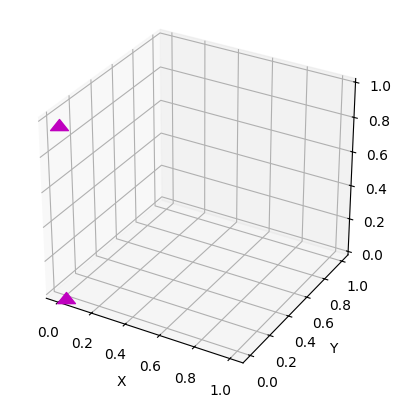

In [651]:
opsv.plot_defo()
ops.wipe()

### Plot force and deformation

In [652]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_out_files(file_paths, title="Data Comparison", save_path=None):
    """
    Plots data from multiple .out files for comparison.

    Args:
        file_paths (list): A list of paths to the .out files.
        title (str): The title of the plot.
        save_path (str, optional): The path to save the plot image (e.g., "plot.png").
                                   If None, the plot will be displayed.
    """
    plt.figure(figsize=(10, 6))

    for file_path in file_paths:
        if not os.path.exists(file_path):
            print(f"Warning: File not found - {file_path}. Skipping.")
            continue

        try:
            # Read data, skipping empty lines
            data = []
            with open(file_path, 'r') as f:
                for line in f:
                    stripped_line = line.strip()
                    if stripped_line: # Check if the line is not empty
                        data.append(list(map(float, stripped_line.split())))

            if not data:
                print(f"Warning: No valid data found in {file_path}. Skipping.")
                continue

            data = np.array(data)

            x = data[:, 0]  # First column is the independent variable (x-axis)
            # Plot each subsequent column as a separate line
            for i in range(1, data.shape[1]):
                y = data[:, i]
                plt.plot(x, y, label=f"{os.path.basename(file_path)} - Column {i+1}")

        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            continue

    plt.xlabel("X-axis (Column 1)")
    plt.ylabel("Y-axis")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

to check connectivity and the ground motion

In [653]:
my_files = [r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\outputs\Qcore_cTc\examppress.out", r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\Qcore\press.out" ]

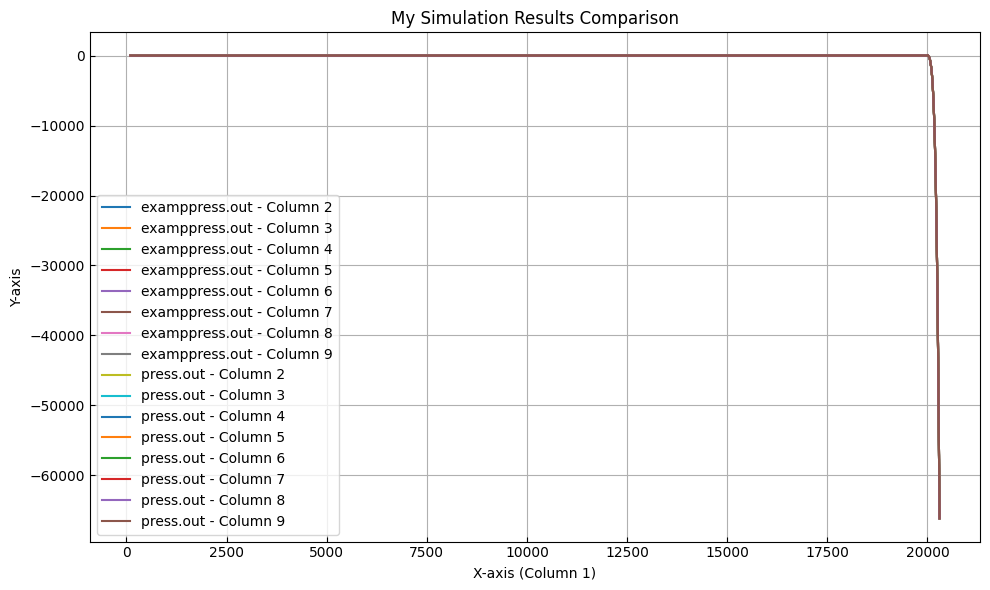

In [654]:
plot_out_files(my_files, title="My Simulation Results Comparison")

In [655]:
my_files = [r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\outputs\Qcore_cTc\exampstress.out", r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\outputs\Qcore_cTc\exampstress.out" ]

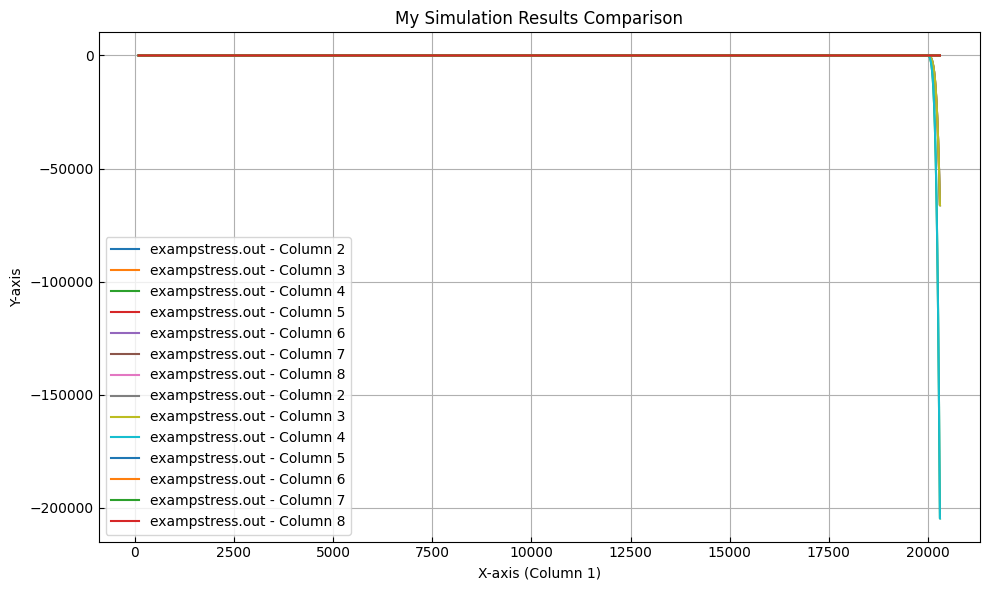

In [656]:
plot_out_files(my_files, title="My Simulation Results Comparison")

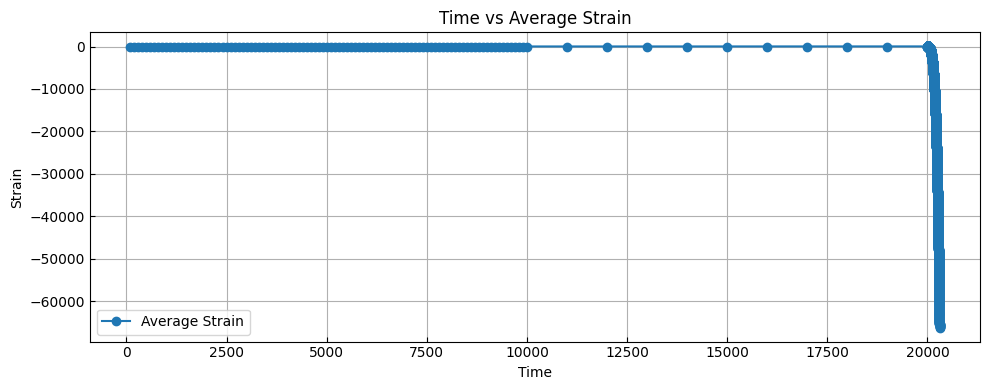

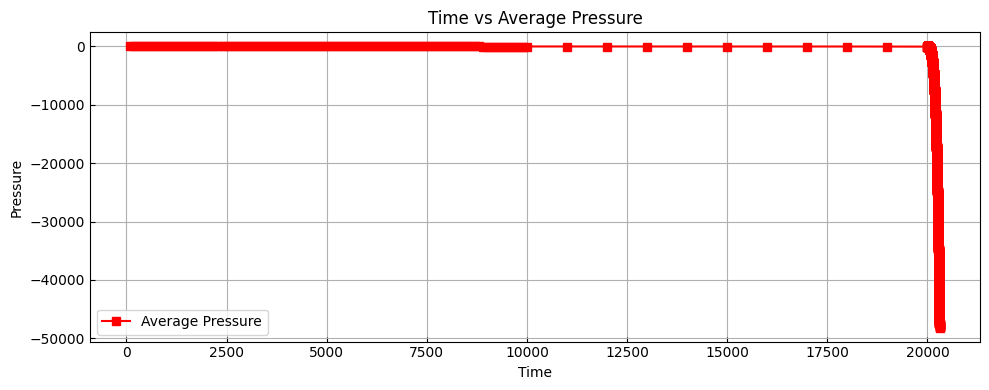

In [657]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
stress_data = np.loadtxt(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\Qcore\press.out")
pressure_data = np.loadtxt(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\Qcore\stress.out")

# Extract time
time_stress = stress_data[:, 0]
time_pressure = pressure_data[:, 0]

# Compute average strain (mean of columns 1-3)
avg_strain = stress_data[:, 1:4].mean(axis=1)

# Compute average pressure (mean of columns 1-8)
avg_pressure = pressure_data[:, 1:].mean(axis=1)

# Plot strain
plt.figure(figsize=(10, 4))
plt.plot(time_stress, avg_strain, marker='o', label='Average Strain')
plt.xlabel('Time')
plt.ylabel('Strain')
plt.title('Time vs Average Strain')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot pressure
plt.figure(figsize=(10, 4))
plt.plot(time_pressure, avg_pressure, marker='s', color='r', label='Average Pressure')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.title('Time vs Average Pressure')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [658]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


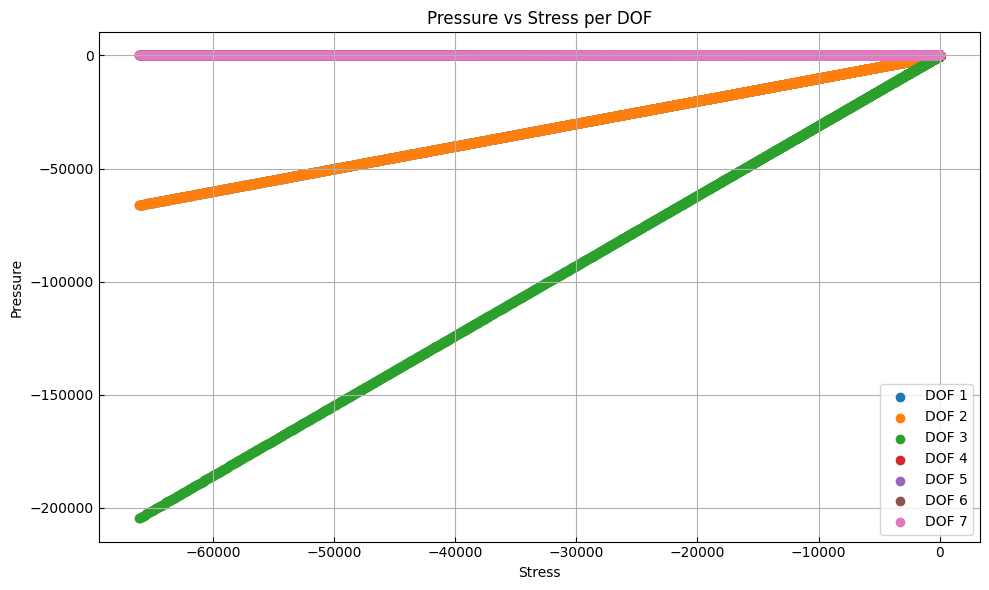

C:\Users\micha\AppData\Local\Temp\ipykernel_16336\2896761638.py:29: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



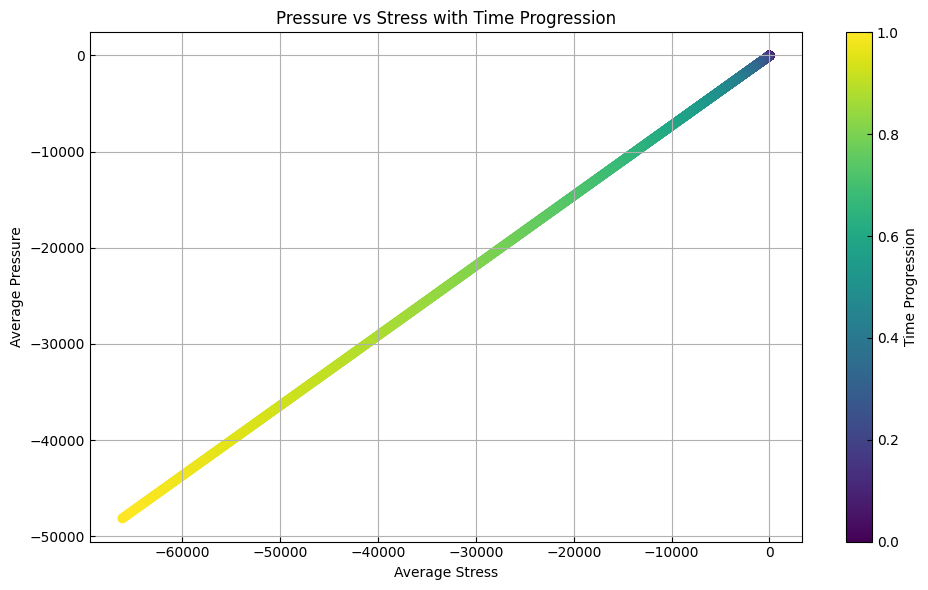

In [659]:
# Extract data excluding time (start from second column)
stress_values = stress_data[:, 1:]  # shape (n, 7)
pressure_values = pressure_data[:, 1:]  # shape (n, 8)

# Match dimensions by truncating the extra pressure column
pressure_values = pressure_values[:, :7]

# Generate color map for time progression
n_samples = stress_values.shape[0]
colors = cm.viridis(np.linspace(0, 1, n_samples))

# Plot DOF-wise Pressure vs Stress
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.scatter(stress_values[:, i], pressure_values[:, i], label=f'DOF {i+1}')

plt.xlabel('Stress')
plt.ylabel('Pressure')
plt.title('Pressure vs Stress per DOF')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot with time progression color
plt.figure(figsize=(10, 6))
avg_stress = stress_values.mean(axis=1)
avg_pressure = pressure_values.mean(axis=1)
plt.scatter(avg_stress, avg_pressure, c=colors, cmap='viridis')
plt.xlabel('Average Stress')
plt.ylabel('Average Pressure')
plt.title('Pressure vs Stress with Time Progression')
plt.grid(True)
plt.colorbar(label='Time Progression')
plt.tight_layout()
plt.show()


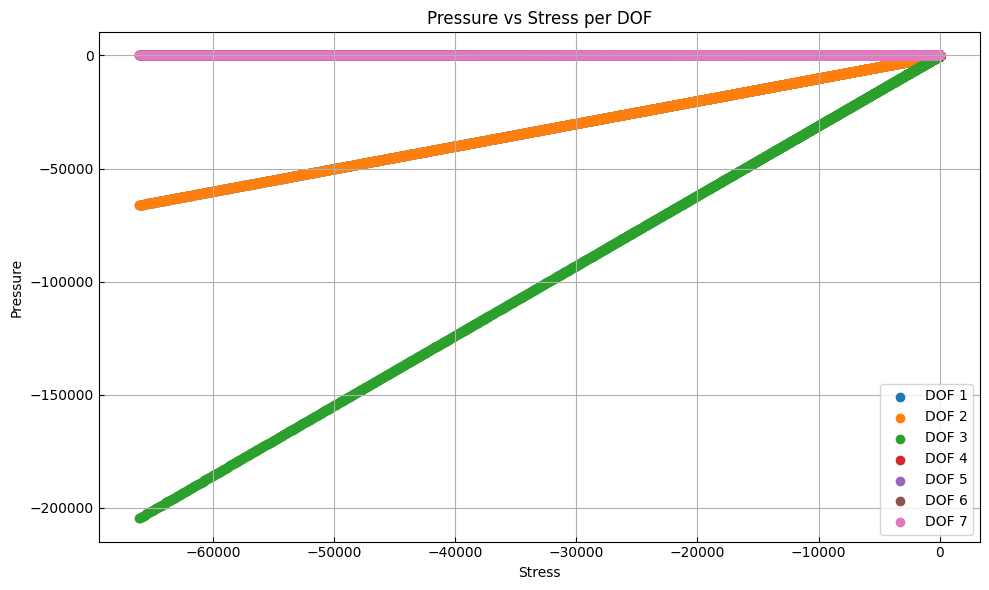

C:\Users\micha\AppData\Local\Temp\ipykernel_16336\2013377897.py:32: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



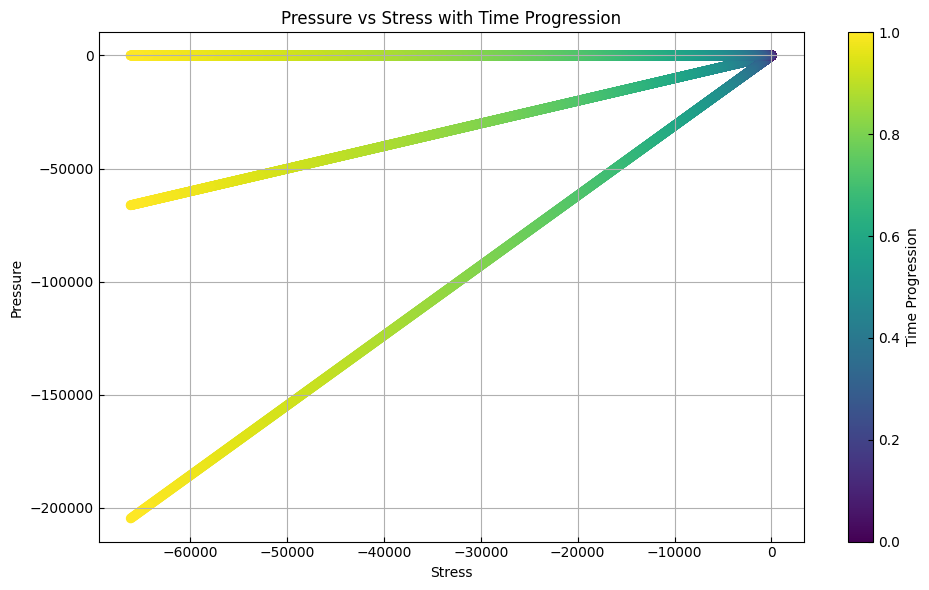

In [660]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Extract data excluding time (start from second column)
stress_values = stress_data[:, 1:]  # shape (n, 7)
pressure_values = pressure_data[:, 1:]  # shape (n, 8)

# Match dimensions by truncating the extra pressure column
pressure_values = pressure_values[:, :7]

# Generate color map for time progression
n_samples = stress_values.shape[0]
colors = cm.viridis(np.linspace(0, 1, n_samples))

# Plot DOF-wise Pressure vs Stress (no averaging)
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.scatter(stress_values[:, i], pressure_values[:, i], label=f'DOF {i+1}')

plt.xlabel('Stress')
plt.ylabel('Pressure')
plt.title('Pressure vs Stress per DOF')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot all data points colored by time progression
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.scatter(stress_values[:, i], pressure_values[:, i], c=colors, cmap='viridis')

plt.xlabel('Stress')
plt.ylabel('Pressure')
plt.title('Pressure vs Stress with Time Progression')
plt.grid(True)
plt.colorbar(label='Time Progression')
plt.tight_layout()
plt.show()